In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train=pd.read_csv('/content/Hotel_A_Train_Cleaned (1) (1).csv')

In [ ]:
test= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DPLC/CW/cleaned/Hotel_A_Test_Cleaned.csv')

In [ ]:
val=pd.read_csv('/content/Hotel_A_Validation_Cleaned (1).csv')

##Data Spliting


In [ ]:
# Define the features and the target and dropping irrelavant columns
X_train = train.drop(['Reservation-id', 'Reservation_Status', 'Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_train = train['Reservation_Status']

X_val = val.drop(['Reservation-id', 'Reservation_Status','Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_val = val['Reservation_Status']

##Feature scaling

In [ ]:
# Creating the 'Over Capacity' flag
train['Is_Over_Capacity'] = (train['Total_Guests'] > 5).astype(int)
val['Is_Over_Capacity'] = (val['Total_Guests'] > 5).astype(int)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transforming validation and test data using the same scaler
X_val_scaled = scaler.transform(X_val)

#Converting back to a dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

print("Scaling complete")

Scaling complete


## Model Training


##Random Forest Classifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Old model with automatic balanced weights

In [ ]:
# Initializing the Model
n_estimators=100 means 100 individual trees will vote on the outcome
random_state=42 #ensures results are the same every time it's run
rf_model = RandomForestClassifier(
   n_estimators=200,
   max_depth=20,
   class_weight='balanced', # focuses on cancelations
   random_state=42
)


In [ ]:
# Training the model using the scaled training data with weights
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight={1: 1, 2: 10, 3: 15}, max_depth=20,
                       n_estimators=200, random_state=42)

In [ ]:
# Predicting the scaled validation data
y_pred_val = rf_model.predict(X_val_scaled)

In [ ]:
# Evaluating the model
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val):.2%}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

Validation Accuracy: 58.62%

Classification Report:
              precision    recall  f1-score   support

           1       0.59      1.00      0.74      1602
           2       0.00      0.00      0.00       738
           3       0.00      0.00      0.00       393

    accuracy                           0.59      2733
   macro avg       0.20      0.33      0.25      2733
weighted avg       0.34      0.59      0.43      2733



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


New Model with manual weights

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Model with custom weights to fix the Recall problem
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,             # Reducing slightly to prevent 'memorizing'
    min_samples_leaf=5,       # Preventing the model from being too specific
    class_weight={1: 1, 2: 12, 3: 15},
    random_state=42
)

# Train on your training data
rf_model.fit(X_train_scaled, y_train)

# Model evalutation
y_pred = rf_model.predict(X_val_scaled)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.60      0.45      0.52      1602
           2       0.28      0.57      0.38       738
           3       0.09      0.01      0.01       393

    accuracy                           0.42      2733
   macro avg       0.33      0.34      0.30      2733
weighted avg       0.44      0.42      0.41      2733



In [ ]:
from sklearn.metrics import accuracy_score

# Calculating Accuracy
accuracy = accuracy_score(y_val, y_pred)

print(f"Overall Model Accuracy: {accuracy:.2%}")

Overall Model Accuracy: 42.01%


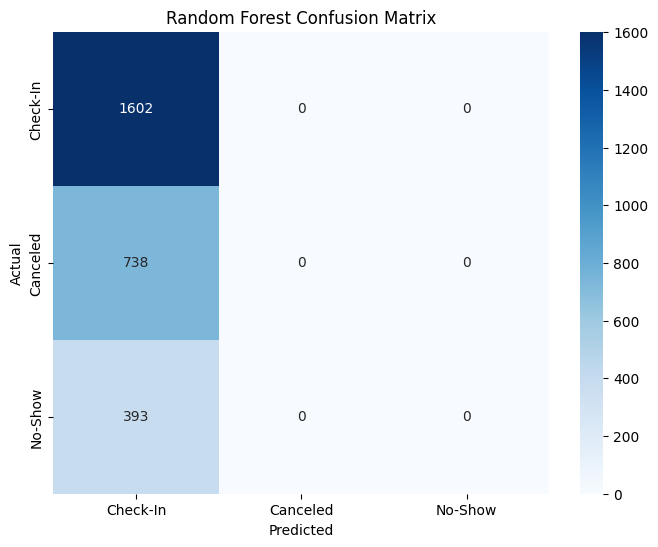

In [ ]:
# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Check-In', 'Canceled', 'No-Show'],
            yticklabels=['Check-In', 'Canceled', 'No-Show'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

## Post Processing

#import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 10 Important Features:")
for f in range(10):
    print(f"{f + 1}. {X_train.columns[indices[f]]} ({importances[indices[f]]:.4f})")

##Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# "Grid" of parameters we want to test
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample'] # CRITICAL for your imbalance issue
}

# Initializing the base model
rf = RandomForestClassifier(random_state=42)

# Initializing the Random Search
# n_iter=10 means it will try 10 random combinations from the grid above
# cv=3 means 3-fold cross-validation
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                               n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)

#Fit the random search model (using your REDUCED feature set)
rf_random.fit(X_train_reduced, y_train)

print("Best Parameters Found:")
print(rf_random.best_params_)

# Using the best model to predict
best_rf = rf_random.best_estimator_
y_pred_best = best_rf.predict(X_val_reduced)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced', 'bootstrap': True}


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print(f"New Accuracy: {accuracy_score(y_val, y_pred_best):.2%}")
print(classification_report(y_val, y_pred_best))

New Accuracy: 58.14%
              precision    recall  f1-score   support

           1       0.59      0.98      0.73      1602
           2       0.31      0.02      0.03       738
           3       0.00      0.00      0.00       393

    accuracy                           0.58      2733
   macro avg       0.30      0.33      0.26      2733
weighted avg       0.43      0.58      0.44      2733

